In [3]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from torchvision.models.segmentation import (
    deeplabv3_resnet101,
    DeepLabV3_ResNet101_Weights
)

In [2]:
weights = DeepLabV3_ResNet101_Weights.DEFAULT
model = deeplabv3_resnet101(weights=weights).eval()
preprocess = weights.transforms()

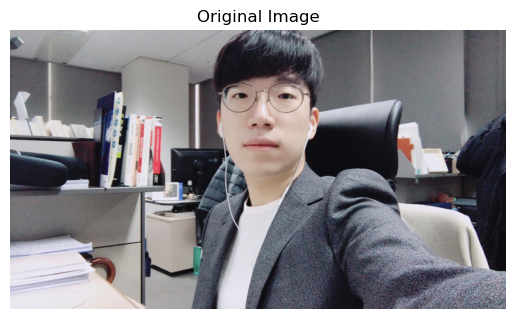

In [4]:
img_path = "images/my_image.png"

img_orig = cv2.imread(img_path)

if img_orig is None:
    raise FileNotFoundError("이미지를 찾지 못했어. images/my_image.png 경로를 확인해줘.")

img_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [6]:
img_path = "images/my_image.png"

img_orig = cv2.imread(img_path)

if img_orig is None:
    raise FileNotFoundError("이미지를 찾지 못했어. images/my_image.png 경로를 확인해줘.")

img_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
img_pil = Image.fromarray(img_rgb)

input_tensor = preprocess(img_pil).unsqueeze(0)

print(input_tensor.shape)

torch.Size([1, 3, 520, 924])


In [7]:
with torch.no_grad():
    output = model(input_tensor)["out"][0]

print(output.shape)

torch.Size([21, 520, 924])


In [8]:
output_predictions = output.argmax(0).byte().cpu().numpy()

output_predictions_resized = cv2.resize(
    output_predictions,
    (img_orig.shape[1], img_orig.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

print(output_predictions_resized.shape)

(450, 800)


In [9]:
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]

unique_classes = np.unique(output_predictions_resized)

for class_id in unique_classes:
    print(class_id, LABEL_NAMES[class_id])

0 background
9 chair
15 person


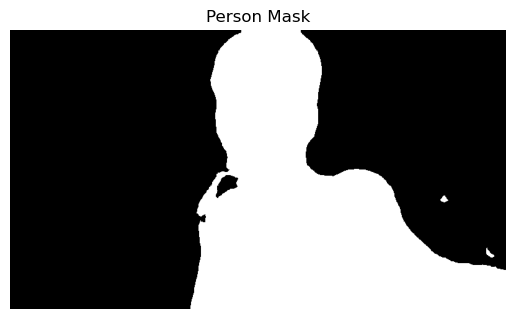

In [10]:
person_mask = (output_predictions_resized == 15).astype(np.uint8) * 255

plt.imshow(person_mask, cmap="gray")
plt.title("Person Mask")
plt.axis("off")
plt.show()

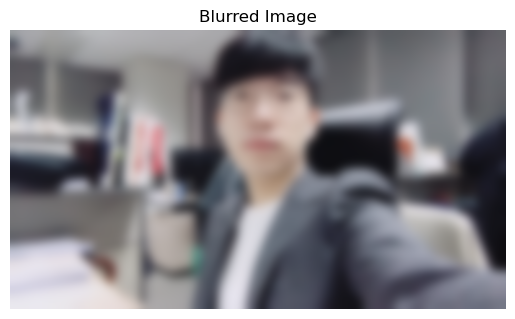

In [11]:
img_blur = cv2.GaussianBlur(img_orig, (51, 51), 0)

img_blur_rgb = cv2.cvtColor(img_blur, cv2.COLOR_BGR2RGB)

plt.imshow(img_blur_rgb)
plt.title("Blurred Image")
plt.axis("off")
plt.show()

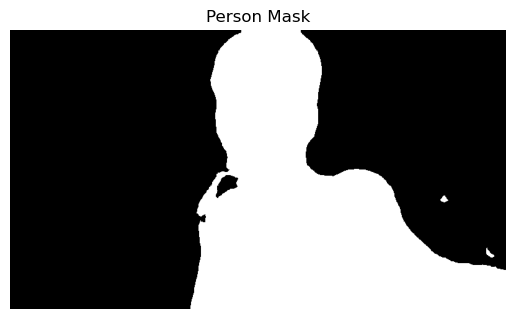

In [14]:
seg_map = (output_predictions_resized == 15)

img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap="gray")
plt.title("Person Mask")
plt.axis("off")
plt.show()

In [18]:
mask_3ch = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

foreground = cv2.bitwise_and(img_orig, mask_3ch)

background_mask = cv2.bitwise_not(img_mask)
background_mask_3ch = cv2.cvtColor(background_mask, cv2.COLOR_GRAY2BGR)

background = cv2.bitwise_and(img_blur, background_mask_3ch)

result = cv2.add(foreground, background)

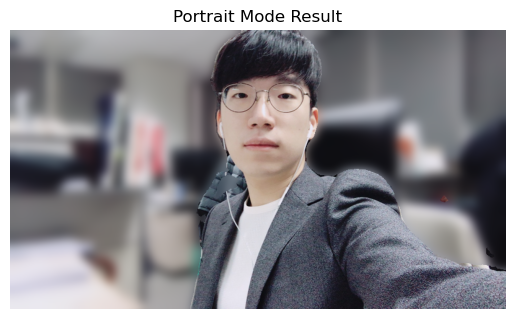

In [19]:
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.imshow(result_rgb)
plt.title("Portrait Mode Result")
plt.axis("off")
plt.show()

In [20]:
print(img_mask.shape)

(450, 800)


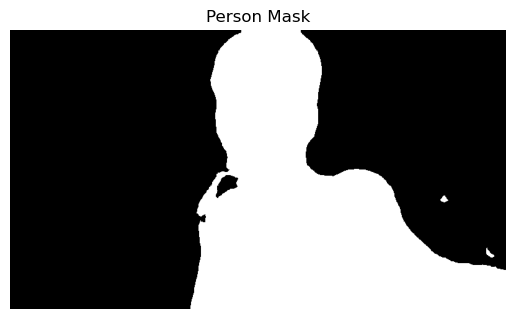

In [21]:
seg_map = (output_predictions_resized == 15)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap="gray")
plt.title("Person Mask")
plt.axis("off")
plt.show()

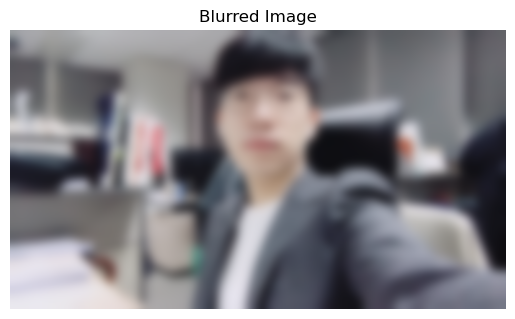

In [22]:
img_blur = cv2.GaussianBlur(img_orig, (51, 51), 0)

plt.imshow(cv2.cvtColor(img_blur, cv2.COLOR_BGR2RGB))
plt.title("Blurred Image")
plt.axis("off")
plt.show()

In [23]:
mask_3ch = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

foreground = cv2.bitwise_and(img_orig, mask_3ch)

background_mask = cv2.bitwise_not(img_mask)
background_mask_3ch = cv2.cvtColor(background_mask, cv2.COLOR_GRAY2BGR)

background = cv2.bitwise_and(img_blur, background_mask_3ch)

result = cv2.add(foreground, background)

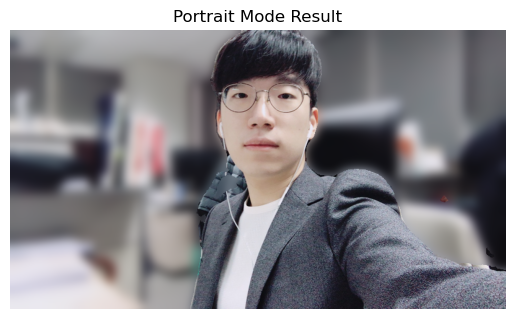

In [24]:
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Portrait Mode Result")
plt.axis("off")
plt.show()

In [25]:
cv2.imwrite("portrait_result.png", result)

True

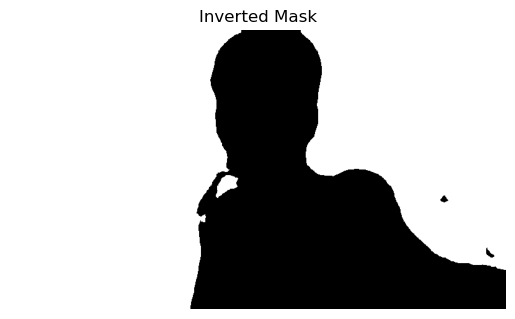

In [28]:
img_mask_inv = cv2.bitwise_not(img_mask)

plt.imshow(img_mask_inv, cmap="gray")
plt.title("Inverted Mask")
plt.axis("off")
plt.show()

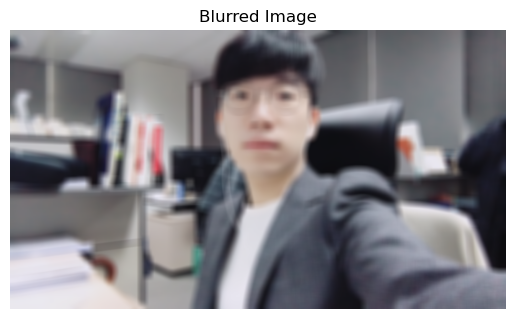

In [33]:
img_orig_blur = cv2.blur(img_orig, (13, 13))

plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
plt.title("Blurred Image")
plt.axis("off")
plt.show()

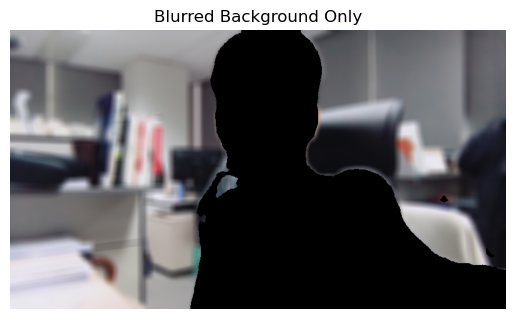

In [34]:
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

img_bg_mask = cv2.bitwise_not(img_mask_color)

img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)

plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.title("Blurred Background Only")
plt.axis("off")
plt.show()

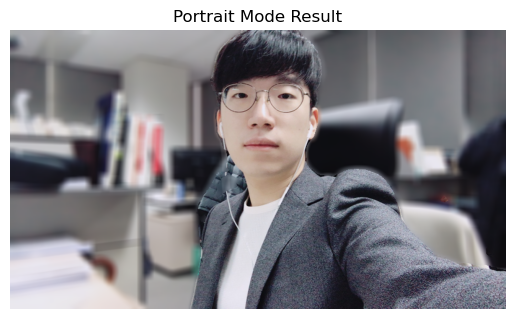

In [35]:
img_concat = np.where(img_mask_color == 255, img_orig, img_bg_blur)

plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.title("Portrait Mode Result")
plt.axis("off")
plt.show()

In [27]:
person_problem_marked = img_concat.copy()

cv2.rectangle(person_problem_marked, (100, 80), (320, 280), (0, 0, 255), 5)
cv2.rectangle(person_problem_marked, (300, 250), (560, 500), (0, 0, 255), 5)

plt.imshow(cv2.cvtColor(person_problem_marked, cv2.COLOR_BGR2RGB))
plt.title("Problem Areas in Person Portrait Mode")
plt.axis("off")
plt.show()

cv2.imwrite("person_problem_marked.png", person_problem_marked)

NameError: name 'img_concat' is not defined

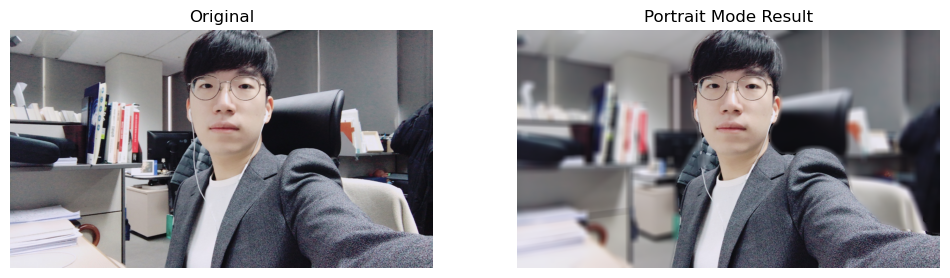

In [37]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.title("Portrait Mode Result")
plt.axis("off")

plt.show()

[실습 회고] 2. 사람 인물모드 사진에서 문제점 찾기

제작한 사람 인물모드 결과를 확인해 보니, segmentation mask가 완벽하지 않아 피사체와 배경의 경계가 어색하게 나타날 수 있었다. 
특히 머리카락, 옷 가장자리, 손처럼 얇고 복잡한 부분은 정확하게 분리되지 않을 가능성이 있다.

또한 배경에 있는 물체가 사람 영역으로 잘못 포함되면, 원래 blur 처리되어야 할 배경이 선명하게 남는 문제가 발생할 수 있다. 
이는 DeepLabV3 모델이 생성한 semantic segmentation mask가 모든 픽셀을 완벽하게 분류하지 못하기 때문에 생기는 한계이다.

이 부분은 고양이 미션에서도 다른 형태로 나타났다.

In [38]:
cv2.imwrite("portrait_result.png", img_concat)

True

In [2]:
import os

print("현재 폴더:", os.getcwd())
print("현재 폴더 파일 목록:", os.listdir())

print("cat.jpg 존재:", os.path.exists("cat.jpg"))
print("sand.jpg 존재:", os.path.exists("sand.jpg"))

현재 폴더: /home/jovyan/work/human_segmentation
현재 폴더 파일 목록: ['images', 'Untitled.ipynb', 'portrait_result.png', ']', '.ipynb_checkpoints', 'models']
cat.jpg 존재: False
sand.jpg 존재: False


In [4]:
import os

print("cat.jpg 존재:", os.path.exists("cat.jpg"))
print("sand.jpg 존재:", os.path.exists("sand.jpg"))

cat.jpg 존재: True
sand.jpg 존재: True


In [5]:
import os

print("cat.jpg 존재:", os.path.exists("cat.jpg"))
print("sand.jpg 존재:", os.path.exists("sand.jpg"))

cat.jpg 존재: True
sand.jpg 존재: True


In [6]:
import os

print("현재 폴더:", os.getcwd())
print("파일 목록:", os.listdir())

print("cat.jpg 존재:", os.path.exists("cat.jpg"))
print("sand.jpg 존재:", os.path.exists("sand.jpg"))

현재 폴더: /home/jovyan/work/human_segmentation
파일 목록: ['images', 'Untitled.ipynb', 'portrait_result.png', 'sand.jpg', ']', 'cat.jpg', '.ipynb_checkpoints', 'models']
cat.jpg 존재: True
sand.jpg 존재: True


In [8]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt
import os

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


In [9]:
print("현재 폴더:", os.getcwd())
print("파일 목록:", os.listdir())

print("cat.jpg 존재:", os.path.exists("cat.jpg"))
print("sand.jpg 존재:", os.path.exists("sand.jpg"))

현재 폴더: /home/jovyan/work/human_segmentation
파일 목록: ['images', 'Untitled.ipynb', 'portrait_result.png', 'sand.jpg', ']', 'cat.jpg', '.ipynb_checkpoints', 'models']
cat.jpg 존재: True
sand.jpg 존재: True


In [10]:
cat_img_path = "cat.jpg"
sand_img_path = "sand.jpg"

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

if cat_img is None:
    raise FileNotFoundError("cat.jpg를 불러오지 못했어. 파일 이름이나 위치를 확인해줘.")

if sand_img is None:
    raise FileNotFoundError("sand.jpg를 불러오지 못했어. 파일 이름이나 위치를 확인해줘.")

print("고양이 이미지 크기:", cat_img.shape)
print("사막 이미지 크기:", sand_img.shape)

고양이 이미지 크기: (1104, 736, 3)
사막 이미지 크기: (480, 576, 3)


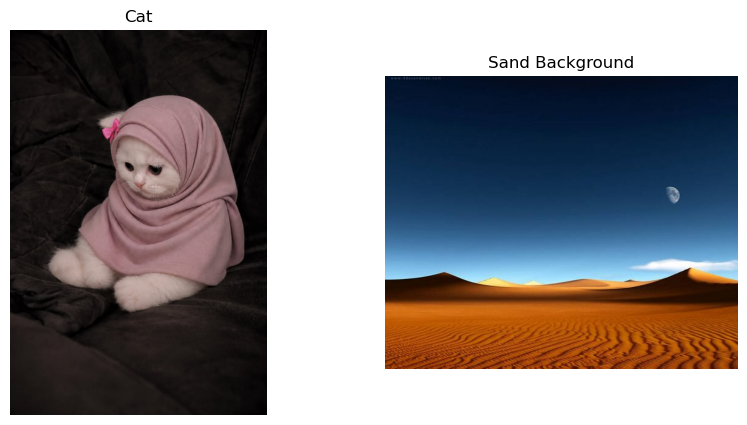

In [11]:
cat_img_rgb = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img_rgb = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cat_img_rgb)
plt.title("Cat")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sand_img_rgb)
plt.title("Sand Background")
plt.axis("off")

plt.show()

In [13]:
import os
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

In [15]:
cat_img_path = "cat.jpg"
sand_img_path = "sand.jpg"

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

if cat_img is None:
    raise FileNotFoundError("cat.jpg를 불러오지 못했어.")

if sand_img is None:
    raise FileNotFoundError("sand.jpg를 불러오지 못했어.")

cat_img_rgb = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)

In [17]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),
    T.ToTensor(),
])

In [18]:
input_tensor = transform(cat_img_rgb).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

In [19]:
output_predictions_resized = cv2.resize(
    output_predictions,
    (cat_img.shape[1], cat_img.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

In [22]:
CAT_CLASS_ID = 8
cat_mask = (output_predictions_resized == CAT_CLASS_ID).astype(np.uint8) * 255

sand_resized = cv2.resize(
    sand_img,
    (cat_img.shape[1], cat_img.shape[0])
)

In [23]:
cat_mask_color = cv2.cvtColor(cat_mask, cv2.COLOR_GRAY2BGR)
cat_chroma_result = np.where(cat_mask_color == 255, cat_img, sand_resized)

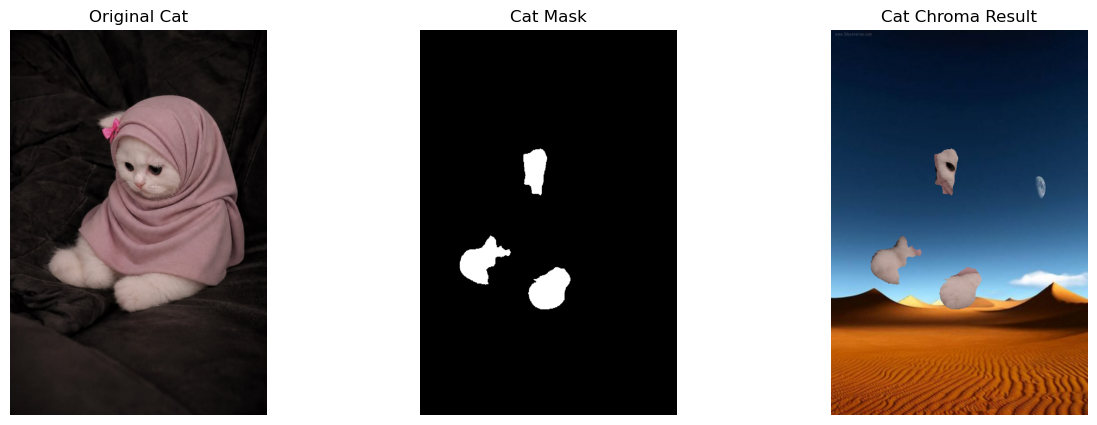

In [26]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB))
plt.title("Original Cat")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cat_mask, cmap="gray")
plt.title("Cat Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(cat_chroma_result, cv2.COLOR_BGR2RGB))
plt.title("Cat Chroma Result")
plt.axis("off")

plt.show()

In [25]:
cv2.imwrite("cat_chroma_result.png", cat_chroma_result)
print("저장 완료:", os.path.exists("cat_chroma_result.png"))

저장 완료: True


[실습 회고] 개인별 고양이와 사막 사진 크로마키 만들기
히잡 쓴 고양이를 활용해 
고양이가 가진 몸통과 외적인 특징을 그대로 들고와서 크로마키가 되는 것이 아닌... 
히잡을 쓴 부분을 고양이로 인식하지 못하는 점이 아쉬웠다.